# Predicting Patient Improvement After Mitral Valve Surgery
### A Professional Healthcare Risk Prediction Analysis

---

## Project Overview

This notebook analyses data from 1,000 patients who underwent mitral valve surgery.
The goal is to predict whether a patient shows clinical improvement 12 months post-surgery.

We test six machine learning models, provide full statistical evaluation, and deliver
an **honest clinical assessment** of what the data can and cannot tell us.

> **Key Finding:** The available patient variables (surgery type, gender, smoking, baseline status)
> are not sufficient to predict post-surgical improvement. All models perform near random chance (AUC ≈ 0.50).
> This is an important clinical finding — it tells us what additional data is needed.

---

### Structure
1. Data Loading & Quality Assurance  
2. Exploratory Data Analysis  
3. Feature Engineering  
4. Modelling Pipeline (6 models)  
5. Evaluation: AUC, Sensitivity, Specificity, F1, Calibration  
6. Interpretability: Feature Importance, Threshold Analysis  
7. Clinical Interpretation & Recommendations  


In [1]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, f1_score, brier_score_loss,
    classification_report)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

np.random.seed(42)

# ─── Colour palette ───────────────────────────────────────────────────────────
CLR_IMPROVED   = '#2196F3'   # blue  — improved
CLR_NO_IMPROVE = '#F44336'   # red   — not improved
CLR_GOLD       = '#FF9800'   # orange
BG             = '#F8F9FA'

MODEL_COLORS = {
    'No-Skill Baseline': '#B0BEC5',
    'Logistic Regression': '#2196F3',
    'KNN': '#FF9800',
    'SVM (RBF)': '#9C27B0',
    'Random Forest': '#4CAF50',
    'Gradient Boosting': '#F44336',
}

def ax_style(ax, title=None):
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    if title: ax.set_title(title, fontweight='bold', fontsize=10)
    return ax

print("✓ Imports complete")


✓ Imports complete


## 1. Data Loading & Quality Assurance

In [2]:
# ─── Load ────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('mitral_valve.csv')
df_raw = df_raw.drop(columns=['Unnamed: 0', 'Subject'])
df_raw.columns = ['surgery_type', 'gender', 'smoker', 'baseline_improved', 'improved_post_surgery']

print("Dataset shape:", df_raw.shape)
print()
display(df_raw.head(8))
print()
print("Missing values:", df_raw.isnull().sum().sum())
print()
print("Value counts per column:")
for col in df_raw.columns:
    print(f"  {col}: {dict(df_raw[col].value_counts())}")


Dataset shape: (1000, 5)



,surgery_type,gender,smoker,baseline_improved,improved_post_surgery
0,Mini,Female,Yes,Yes,Yes
1,Conventional,Female,No,No,Yes
2,Conventional,Female,Yes,No,No
3,Conventional,Female,Yes,No,Yes
4,Conventional,Male,Yes,Yes,No
5,Conventional,Male,No,No,No
6,Conventional,Male,Yes,Yes,Yes
7,Conventional,Female,No,No,No



Missing values: 0

Value counts per column:
  surgery_type: {'Conventional': 501, 'Mini': 499}
  gender: {'Female': 504, 'Male': 496}
  smoker: {'Yes': 508, 'No': 492}
  baseline_improved: {'No': 504, 'Yes': 496}
  improved_post_surgery: {'No': 531, 'Yes': 469}


In [3]:
# ─── Data quality assertions ─────────────────────────────────────────────────
assert df_raw.isnull().sum().sum() == 0,                          "No nulls expected"
assert set(df_raw['surgery_type'].unique()) == {'Mini', 'Conventional'}, "Surgery types"
assert set(df_raw['gender'].unique()) == {'Male', 'Female'},      "Gender values"
assert set(df_raw['smoker'].unique()) == {'Yes', 'No'},           "Smoker values"
assert set(df_raw['improved_post_surgery'].unique()) == {'Yes', 'No'}, "Target binary"

# Class balance
n_improved = (df_raw['improved_post_surgery'] == 'Yes').sum()
n_total    = len(df_raw)
print(f"✓ All assertions passed")
print(f"\nClass balance:")
print(f"  Improved     : {n_improved:,} ({n_improved/n_total:.1%})")
print(f"  Not Improved : {n_total-n_improved:,} ({(n_total-n_improved)/n_total:.1%})")
print(f"\nConclusion: Near-balanced dataset — class imbalance correction NOT required.")


✓ All assertions passed

Class balance:
  Improved     : 469 (46.9%)
  Not Improved : 531 (53.1%)

Conclusion: Near-balanced dataset — class imbalance correction NOT required.


## 2. Exploratory Data Analysis

Before building models, we explore the data to understand distributions and test whether
any variable is statistically associated with the outcome.

> **Chi-squared test:** Tests whether two categorical variables are independent.
> If p < 0.05, the variables are significantly associated. If p > 0.05, we cannot
> detect a meaningful relationship.


In [4]:
# ─── Statistical association tests ───────────────────────────────────────────
vars_to_test = {
    'Surgery Type':    ('surgery_type', 'improved_post_surgery'),
    'Gender':          ('gender', 'improved_post_surgery'),
    'Smoking':         ('smoker', 'improved_post_surgery'),
    'Baseline Status': ('baseline_improved', 'improved_post_surgery'),
}

print("Chi-squared Association Tests (Are predictors linked to the outcome?)")
print("="*65)
chi2_results = []
for label, (v1, v2) in vars_to_test.items():
    ct = pd.crosstab(df_raw[v1], df_raw[v2])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = "SIGNIFICANT ✓" if p < 0.05 else "Not significant ✗"
    chi2_results.append({'Variable': label, 'Chi²': chi2, 'p-value': p})
    print(f"  {label:20s}: Chi²={chi2:.3f}  p={p:.4f}  → {sig}")

print()
print("⚠ FINDING: None of the available variables are statistically")
print("  associated with post-surgical improvement (all p > 0.13).")
print("  This is the core reason models cannot predict well.")


Chi-squared Association Tests (Are predictors linked to the outcome?)
  Surgery Type        : Chi²=0.103  p=0.7484  → Not significant ✗
  Gender              : Chi²=0.815  p=0.3666  → Not significant ✗
  Smoking             : Chi²=1.231  p=0.2673  → Not significant ✗
  Baseline Status     : Chi²=2.265  p=0.1323  → Not significant ✗

⚠ FINDING: None of the available variables are statistically
  associated with post-surgical improvement (all p > 0.13).
  This is the core reason models cannot predict well.


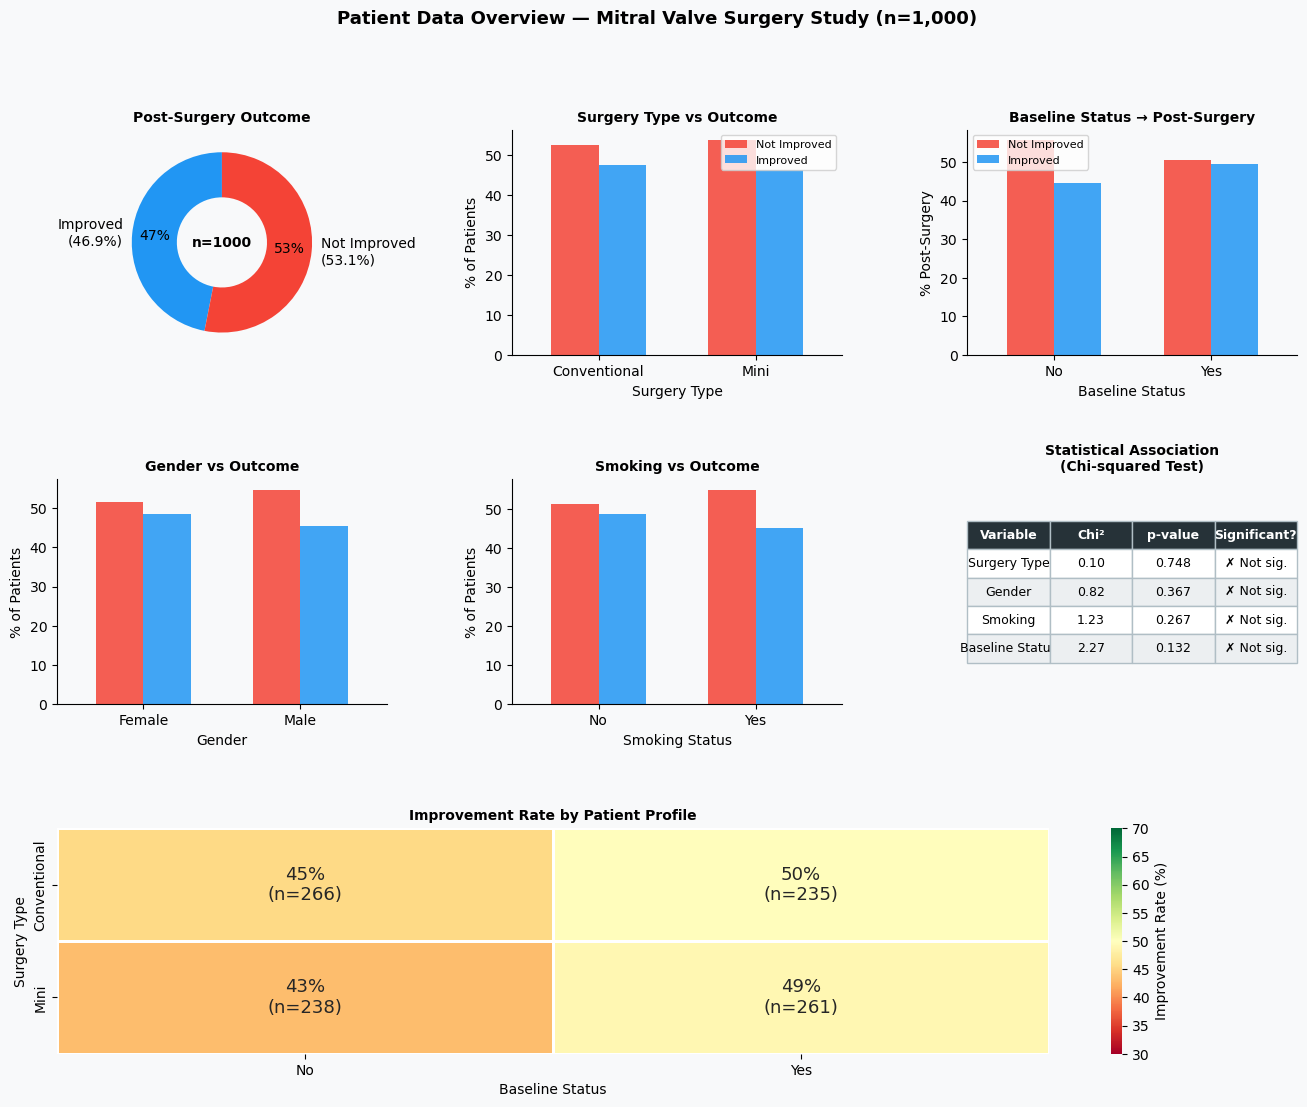

In [5]:
# ─── EDA Visualisations ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12), facecolor=BG)
fig.suptitle('Patient Data Overview — Mitral Valve Surgery Study (n=1,000)',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# Outcome donut
ax1 = ax_style(fig.add_subplot(gs[0, 0]), 'Post-Surgery Outcome')
improved = (df_raw['improved_post_surgery']=='Yes').sum()
ax1.pie([improved, len(df_raw)-improved],
        labels=['Improved\n(46.9%)','Not Improved\n(53.1%)'],
        colors=[CLR_IMPROVED, CLR_NO_IMPROVE],
        autopct='%1.0f%%', startangle=90, pctdistance=0.75,
        wedgeprops=dict(width=0.5))
ax1.text(0, 0, f'n={len(df_raw)}', ha='center', va='center', fontsize=10, fontweight='bold')

# Surgery type → outcome
ax2 = ax_style(fig.add_subplot(gs[0, 1]), 'Surgery Type vs Outcome')
surg_pct = df_raw.groupby(['surgery_type','improved_post_surgery']).size().unstack(fill_value=0)
surg_pct = surg_pct.div(surg_pct.sum(axis=1), axis=0) * 100
surg_pct.plot(kind='bar', ax=ax2, color=[CLR_NO_IMPROVE, CLR_IMPROVED], alpha=0.85, width=0.6)
ax2.set_xlabel('Surgery Type'); ax2.set_ylabel('% of Patients')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(['Not Improved','Improved'], fontsize=8)

# Baseline → Post-surgery transition
ax3 = ax_style(fig.add_subplot(gs[0, 2]), 'Baseline Status → Post-Surgery')
trans = df_raw.groupby(['baseline_improved','improved_post_surgery']).size().unstack(fill_value=0)
trans_pct = trans.div(trans.sum(axis=1), axis=0) * 100
trans_pct.plot(kind='bar', ax=ax3, color=[CLR_NO_IMPROVE, CLR_IMPROVED], alpha=0.85, width=0.6)
ax3.set_xlabel('Baseline Status'); ax3.set_ylabel('% Post-Surgery')
ax3.tick_params(axis='x', rotation=0)
ax3.legend(['Not Improved','Improved'], fontsize=8)

# Gender → outcome
ax4 = ax_style(fig.add_subplot(gs[1, 0]), 'Gender vs Outcome')
gen_pct = df_raw.groupby(['gender','improved_post_surgery']).size().unstack(fill_value=0)
gen_pct = gen_pct.div(gen_pct.sum(axis=1), axis=0) * 100
gen_pct.plot(kind='bar', ax=ax4, color=[CLR_NO_IMPROVE, CLR_IMPROVED], alpha=0.85, width=0.6, legend=False)
ax4.set_xlabel('Gender'); ax4.set_ylabel('% of Patients')
ax4.tick_params(axis='x', rotation=0)

# Smoking → outcome
ax5 = ax_style(fig.add_subplot(gs[1, 1]), 'Smoking vs Outcome')
smk_pct = df_raw.groupby(['smoker','improved_post_surgery']).size().unstack(fill_value=0)
smk_pct = smk_pct.div(smk_pct.sum(axis=1), axis=0) * 100
smk_pct.plot(kind='bar', ax=ax5, color=[CLR_NO_IMPROVE, CLR_IMPROVED], alpha=0.85, width=0.6, legend=False)
ax5.set_xlabel('Smoking Status'); ax5.set_ylabel('% of Patients')
ax5.tick_params(axis='x', rotation=0)

# Chi2 results table
ax6 = ax_style(fig.add_subplot(gs[1, 2]), 'Statistical Association\n(Chi-squared Test)')
ax6.axis('off')
chi2_df = pd.DataFrame(chi2_results)
tbl = ax6.table(
    cellText=[[r['Variable'], f"{r['Chi²']:.2f}", f"{r['p-value']:.3f}",
               '✓ p<0.05' if r['p-value'] < 0.05 else '✗ Not sig.']
              for _, r in chi2_df.iterrows()],
    colLabels=['Variable', 'Chi²', 'p-value', 'Significant?'],
    cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#263238'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#ECEFF1')
    cell.set_edgecolor('#B0BEC5')

# Profile heatmap
ax7 = ax_style(fig.add_subplot(gs[2, :]), 'Improvement Rate by Patient Profile')
profile_data = []
for surg in ['Mini', 'Conventional']:
    for base in ['Yes', 'No']:
        sub = df_raw[(df_raw['surgery_type']==surg) & (df_raw['baseline_improved']==base)]
        rate = (sub['improved_post_surgery']=='Yes').mean()*100
        profile_data.append({'Surgery': surg, 'Baseline': base,
                              'Improvement Rate': rate, 'label': f'{rate:.0f}%\n(n={len(sub)})'})
prof_df = pd.DataFrame(profile_data)
pivot_rate = prof_df.pivot(index='Surgery', columns='Baseline', values='Improvement Rate')
pivot_n    = prof_df.pivot(index='Surgery', columns='Baseline', values='label')
sns.heatmap(pivot_rate, ax=ax7, annot=pivot_n, fmt='', cmap='RdYlGn',
            vmin=30, vmax=70, linewidths=1, linecolor='white',
            cbar_kws={'label': 'Improvement Rate (%)'}, annot_kws={'size': 13})
ax7.set_xlabel('Baseline Status'); ax7.set_ylabel('Surgery Type')

plt.tight_layout()
plt.show()


## 3. Feature Engineering & Data Preparation

In [6]:
# ─── Encode + engineer features ──────────────────────────────────────────────
df = df_raw.copy()

# Binary encoding (no dummy trap since all are binary)
df['target']              = (df['improved_post_surgery'] == 'Yes').astype(int)
df['baseline_improved_n'] = (df['baseline_improved'] == 'Yes').astype(int)
df['surgery_mini']        = (df['surgery_type'] == 'Mini').astype(int)
df['gender_male']         = (df['gender'] == 'Male').astype(int)
df['smoker_yes']          = (df['smoker'] == 'Yes').astype(int)

# Clinically motivated interaction: does baseline improvement + mini surgery predict better outcomes?
df['baseline_x_surgery']  = df['baseline_improved_n'] * df['surgery_mini']

FEATURES     = ['surgery_mini', 'gender_male', 'smoker_yes', 'baseline_improved_n', 'baseline_x_surgery']
FEAT_LABELS  = ['Mini Surgery', 'Male Gender', 'Smoker', 'Baseline Improved', 'Baseline × Mini Surgery']
X = df[FEATURES].values
y = df['target'].values

# ─── Train / test split ───────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {len(X_tr):,} patients  |  Test: {len(X_te):,} patients")
print(f"Train improvement rate: {y_tr.mean():.1%}")
print(f"Test  improvement rate: {y_te.mean():.1%}")

# ─── Scale (important for KNN and SVM) ───────────────────────────────────────
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

print("\n✓ Feature engineering complete. Features:", FEATURES)


Train: 800 patients  |  Test: 200 patients
Train improvement rate: 46.9%
Test  improvement rate: 47.0%

✓ Feature engineering complete. Features: ['surgery_mini', 'gender_male', 'smoker_yes', 'baseline_improved_n', 'baseline_x_surgery']


## 4. Modelling Pipeline

We train six models and evaluate each on the same held-out test set.

| Model | Description |
|-------|-------------|
| No-Skill Baseline | Always predicts majority class — our floor |
| Logistic Regression | Linear probability model — standard clinical baseline |
| KNN (k=15) | Similarity-based classifier |
| SVM (RBF kernel) | Margin-based classifier with non-linear boundary |
| Random Forest (n=200) | Ensemble of decision trees |
| Gradient Boosting (n=200) | Sequential tree ensemble |

All models are probability-calibrated where needed.  
Validation: 10-fold stratified cross-validation + held-out test set.


In [7]:
# ─── Model definitions ───────────────────────────────────────────────────────
model_specs = {
    'No-Skill Baseline':  DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression':LogisticRegression(C=1.0, max_iter=500, random_state=42),
    'KNN':                KNeighborsClassifier(n_neighbors=15),
    'SVM (RBF)':          CalibratedClassifierCV(
                            SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42), cv=5),
    'Random Forest':      RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=200, max_depth=3,
                            learning_rate=0.05, random_state=42),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results, cv_aucs = {}, {}

print("Training and evaluating models…")
print("="*70)

for name, model in model_specs.items():
    model.fit(X_tr_sc, y_tr)
    y_prob = model.predict_proba(X_te_sc)[:, 1]
    y_pred = model.predict(X_te_sc)
    
    if name == 'No-Skill Baseline':
        cv_auc = np.array([0.5]*10)
    else:
        cv_auc = cross_val_score(model, X_tr_sc, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    auc   = roc_auc_score(y_te, y_prob)
    ap    = average_precision_score(y_te, y_prob)
    bs    = brier_score_loss(y_te, y_prob)
    cm    = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sens  = tp/(tp+fn+1e-9); spec = tn/(tn+fp+1e-9)
    ppv   = tp/(tp+fp+1e-9); f1   = f1_score(y_te, y_pred, zero_division=0)
    
    results[name] = {
        'y_prob': y_prob, 'y_pred': y_pred, 'AUC': auc, 'AP': ap, 'Brier': bs,
        'Sensitivity': sens, 'Specificity': spec, 'PPV': ppv, 'F1': f1, 'CM': cm,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    }
    cv_aucs[name] = cv_auc
    print(f"{name:25s} | AUC={auc:.3f} | Sens={sens:.3f} | Spec={spec:.3f} | "
          f"F1={f1:.3f} | CV={np.mean(cv_auc):.3f}±{np.std(cv_auc):.3f}")


Training and evaluating models…
No-Skill Baseline         | AUC=0.500 | Sens=0.000 | Spec=1.000 | F1=0.000 | CV=0.500±0.000
Logistic Regression       | AUC=0.497 | Sens=0.245 | Spec=0.792 | F1=0.331 | CV=0.520±0.047
KNN                       | AUC=0.430 | Sens=0.489 | Spec=0.425 | F1=0.458 | CV=0.516±0.054
SVM (RBF)                 | AUC=0.555 | Sens=0.000 | Spec=1.000 | F1=0.000 | CV=0.458±0.037
Random Forest             | AUC=0.481 | Sens=0.426 | Spec=0.481 | F1=0.423 | CV=0.478±0.057
Gradient Boosting         | AUC=0.486 | Sens=0.404 | Spec=0.604 | F1=0.437 | CV=0.485±0.054


## 5. Evaluation: ROC Curves, Metrics, and Cross-Validation

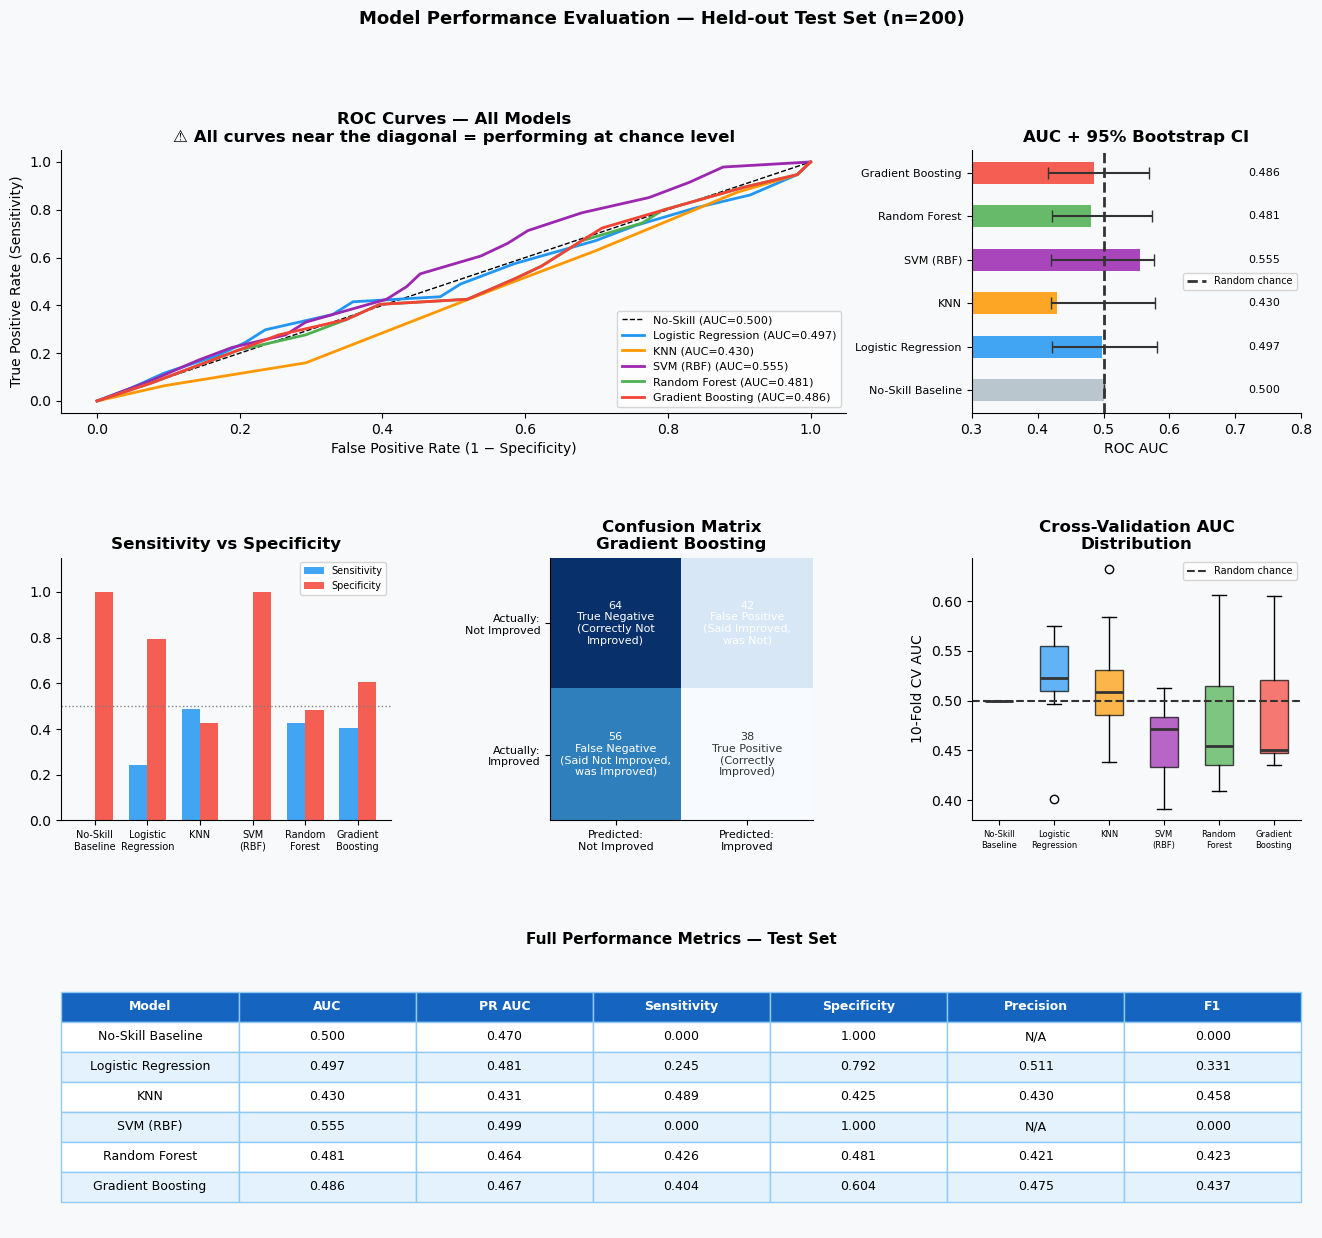

In [9]:
# ─── Full evaluation visualisation ───────────────────────────────────────────
from matplotlib.ticker import FuncFormatter

fig = plt.figure(figsize=(16, 14), facecolor=BG)
fig.suptitle(
    'Model Performance Evaluation — Held-out Test Set (n=200)',
    fontsize=13,
    fontweight='bold'
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# ROC curves
ax1 = ax_style(fig.add_subplot(gs[0, :2]))
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='No-Skill (AUC=0.500)')

for name, res in results.items():
    if name == 'No-Skill Baseline':
        continue
    fpr, tpr, _ = roc_curve(y_te, res['y_prob'])
    ax1.plot(
        fpr, tpr,
        lw=2,
        color=MODEL_COLORS[name],
        label=f"{name} (AUC={res['AUC']:.3f})"
    )

ax1.set_xlabel('False Positive Rate (1 − Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title(
    'ROC Curves — All Models\n⚠ All curves near the diagonal = performing at chance level',
    fontweight='bold'
)
ax1.legend(fontsize=8, loc='lower right')

# AUC bar with bootstrap CIs
ax2 = ax_style(fig.add_subplot(gs[0, 2]))
model_names = list(results.keys())
auc_vals = [results[n]['AUC'] for n in model_names]
boot_ci = {}

for name, res in results.items():
    if name == 'No-Skill Baseline':
        boot_ci[name] = (0.5, 0.5, 0.5)
        continue

    bs_ = [
        roc_auc_score(
            y_te[np.random.choice(len(y_te), len(y_te))],
            res['y_prob'][np.random.choice(len(y_te), len(y_te))]
        )
        for _ in range(500)
    ]
    boot_ci[name] = (
        np.mean(bs_),
        np.percentile(bs_, 2.5),
        np.percentile(bs_, 97.5)
    )

y_pos = np.arange(len(model_names))
ax2.barh(
    y_pos,
    auc_vals,
    color=[MODEL_COLORS[n] for n in model_names],
    alpha=0.85,
    height=0.5
)

for i, name in enumerate(model_names):
    m, lo, hi = boot_ci[name]
    ax2.errorbar(m, i, xerr=[[m - lo], [hi - m]], fmt='none', color='#333', capsize=4, lw=1.5)
    ax2.text(0.72, i, f'{auc_vals[i]:.3f}', va='center', fontsize=8)

ax2.axvline(0.5, color='#333', lw=2, ls='--', label='Random chance')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(model_names, fontsize=8)
ax2.set_xlabel('ROC AUC')
ax2.set_title('AUC + 95% Bootstrap CI', fontweight='bold')
ax2.set_xlim(0.3, 0.8)
ax2.legend(fontsize=7)

# Sensitivity / Specificity
ax3 = ax_style(fig.add_subplot(gs[1, 0]))
x = np.arange(len(model_names))
w = 0.35

ax3.bar(
    x - w / 2,
    [results[n]['Sensitivity'] for n in model_names],
    w,
    label='Sensitivity',
    color=CLR_IMPROVED,
    alpha=0.85
)
ax3.bar(
    x + w / 2,
    [results[n]['Specificity'] for n in model_names],
    w,
    label='Specificity',
    color=CLR_NO_IMPROVE,
    alpha=0.85
)

ax3.set_xticks(x)
ax3.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=7)
ax3.set_title('Sensitivity vs Specificity', fontweight='bold')
ax3.set_ylim(0, 1.15)
ax3.legend(fontsize=7)
ax3.axhline(0.5, color='grey', ls=':', lw=1)

# Confusion matrix (best model)
best = 'Gradient Boosting'
ax4 = ax_style(fig.add_subplot(gs[1, 1]))
cm_data = results[best]['CM']

labels_cm = [
    ['True Negative\n(Correctly Not\nImproved)', 'False Positive\n(Said Improved,\nwas Not)'],
    ['False Negative\n(Said Not Improved,\nwas Improved)', 'True Positive\n(Correctly\nImproved)']
]

im = ax4.imshow(cm_data, cmap='Blues')

for i in range(2):
    for j in range(2):
        clr = 'white' if cm_data[i, j] > cm_data.max() * 0.6 else '#333'
        ax4.text(
            j, i,
            f'{cm_data[i, j]}\n{labels_cm[i][j]}',
            ha='center',
            va='center',
            fontsize=8,
            color=clr
        )

ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Predicted:\nNot Improved', 'Predicted:\nImproved'], fontsize=8)
ax4.set_yticklabels(['Actually:\nNot Improved', 'Actually:\nImproved'], fontsize=8)
ax4.set_title(f'Confusion Matrix\n{best}', fontweight='bold')

# CV AUC box
ax5 = ax_style(fig.add_subplot(gs[1, 2]))
bp = ax5.boxplot(
    [cv_aucs[n] for n in model_names],
    labels=[n.replace(' ', '\n') for n in model_names],
    patch_artist=True,
    medianprops=dict(color='#333', lw=2)
)

for patch, name in zip(bp['boxes'], model_names):
    patch.set_facecolor(MODEL_COLORS[name])
    patch.set_alpha(0.7)

ax5.axhline(0.5, color='#333', ls='--', lw=1.5, label='Random chance')
ax5.set_ylabel('10-Fold CV AUC')
ax5.set_title('Cross-Validation AUC\nDistribution', fontweight='bold')
ax5.tick_params(axis='x', labelsize=6)
ax5.legend(fontsize=7)

# Metrics table
ax6 = ax_style(fig.add_subplot(gs[2, :]))
ax6.axis('off')

rows = [
    [
        n,
        f"{results[n]['AUC']:.3f}",
        f"{results[n]['AP']:.3f}",
        f"{results[n]['Sensitivity']:.3f}",
        f"{results[n]['Specificity']:.3f}",
        f"{results[n]['PPV']:.3f}" if results[n]['PPV'] > 0 else 'N/A',
        f"{results[n]['F1']:.3f}"
    ]
    for n in model_names
]

tbl = ax6.table(
    cellText=rows,
    colLabels=['Model', 'AUC', 'PR AUC', 'Sensitivity', 'Specificity', 'Precision', 'F1'],
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#90CAF9')

ax6.set_title('Full Performance Metrics — Test Set', fontweight='bold', fontsize=11, pad=15)

plt.tight_layout()
plt.show()

## 6. Interpretability — Feature Importance & Threshold Analysis

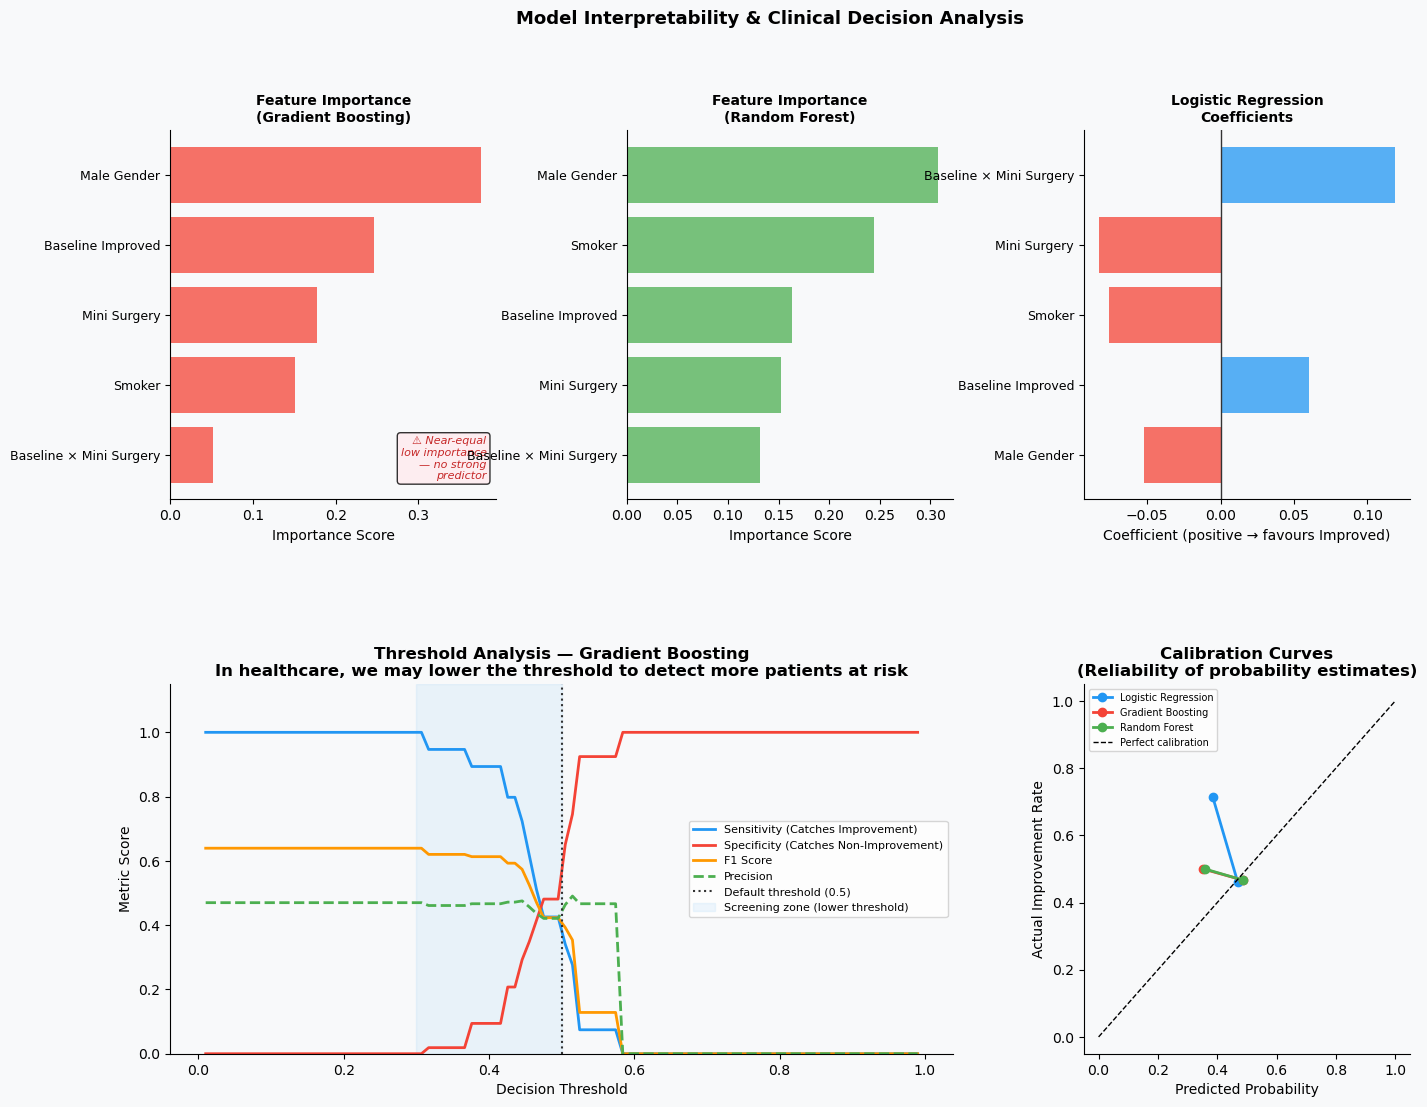

In [10]:
fig = plt.figure(figsize=(16, 12), facecolor=BG)
fig.suptitle('Model Interpretability & Clinical Decision Analysis', fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.40)

# GBM feature importance
ax1 = ax_style(fig.add_subplot(gs[0, 0]), 'Feature Importance\n(Gradient Boosting)')
gbm = model_specs['Gradient Boosting']
fi_gbm = gbm.feature_importances_
idx = np.argsort(fi_gbm)
ax1.barh(range(len(idx)), fi_gbm[idx], color='#F44336', alpha=0.75)
ax1.set_yticks(range(len(idx))); ax1.set_yticklabels([FEAT_LABELS[i] for i in idx], fontsize=9)
ax1.set_xlabel('Importance Score')
ax1.text(0.97, 0.05, '⚠ Near-equal\nlow importance\n— no strong\npredictor',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8, color='#C62828',
         style='italic', bbox=dict(boxstyle='round', facecolor='#FFEBEE', alpha=0.8))

# RF feature importance
ax2 = ax_style(fig.add_subplot(gs[0, 1]), 'Feature Importance\n(Random Forest)')
fi_rf = model_specs['Random Forest'].feature_importances_
idx_rf = np.argsort(fi_rf)
ax2.barh(range(len(idx_rf)), fi_rf[idx_rf], color='#4CAF50', alpha=0.75)
ax2.set_yticks(range(len(idx_rf))); ax2.set_yticklabels([FEAT_LABELS[i] for i in idx_rf], fontsize=9)
ax2.set_xlabel('Importance Score')

# Logistic regression coefficients
ax3 = ax_style(fig.add_subplot(gs[0, 2]), 'Logistic Regression\nCoefficients')
lr = model_specs['Logistic Regression']
coefs = lr.coef_[0]
idx_lr = np.argsort(np.abs(coefs))
bar_colors = [CLR_IMPROVED if c > 0 else CLR_NO_IMPROVE for c in coefs[idx_lr]]
ax3.barh(range(len(idx_lr)), coefs[idx_lr], color=bar_colors, alpha=0.75)
ax3.set_yticks(range(len(idx_lr))); ax3.set_yticklabels([FEAT_LABELS[i] for i in idx_lr], fontsize=9)
ax3.axvline(0, color='#333', lw=1)
ax3.set_xlabel('Coefficient (positive → favours Improved)')

# Threshold analysis
ax4 = ax_style(fig.add_subplot(gs[1, :2]))
thresholds  = np.linspace(0.01, 0.99, 100)
y_prob_gbm  = results['Gradient Boosting']['y_prob']
sens_l, spec_l, f1_l, ppv_l = [], [], [], []
for t in thresholds:
    yp = (y_prob_gbm >= t).astype(int)
    cm = confusion_matrix(y_te, yp, labels=[0,1]).ravel()
    tn_,fp_,fn_,tp_ = cm
    sens_l.append(tp_/(tp_+fn_+1e-9)); spec_l.append(tn_/(tn_+fp_+1e-9))
    ppv_l.append(tp_/(tp_+fp_+1e-9)); f1_l.append(f1_score(y_te, yp, zero_division=0))
ax4.plot(thresholds, sens_l, color=CLR_IMPROVED, lw=2, label='Sensitivity (Catches Improvement)')
ax4.plot(thresholds, spec_l, color=CLR_NO_IMPROVE, lw=2, label='Specificity (Catches Non-Improvement)')
ax4.plot(thresholds, f1_l, color=CLR_GOLD, lw=2, label='F1 Score')
ax4.plot(thresholds, ppv_l, color='#4CAF50', lw=2, ls='--', label='Precision')
ax4.axvline(0.5, color='#333', lw=1.5, ls=':', label='Default threshold (0.5)')
ax4.axvspan(0.3, 0.5, alpha=0.07, color=CLR_IMPROVED, label='Screening zone (lower threshold)')
ax4.set_xlabel('Decision Threshold')
ax4.set_ylabel('Metric Score')
ax4.set_title('Threshold Analysis — Gradient Boosting\nIn healthcare, we may lower the threshold to detect more patients at risk', fontweight='bold')
ax4.legend(fontsize=8, loc='center right'); ax4.set_ylim(0, 1.15)

# Calibration
ax5 = ax_style(fig.add_subplot(gs[1, 2]))
for name in ['Logistic Regression', 'Gradient Boosting', 'Random Forest']:
    y_prob = results[name]['y_prob']
    try:
        pt, pp = calibration_curve(y_te, y_prob, n_bins=5)
        ax5.plot(pp, pt, 'o-', lw=2, color=MODEL_COLORS[name], label=name, ms=6)
    except: pass
ax5.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
ax5.set_xlabel('Predicted Probability'); ax5.set_ylabel('Actual Improvement Rate')
ax5.set_title('Calibration Curves\n(Reliability of probability estimates)', fontweight='bold')
ax5.legend(fontsize=7)

plt.tight_layout(); plt.show()


## 7. Clinical Interpretation & Key Conclusions

### What the Results Mean

| Finding | Implication |
|---------|-------------|
| All models AUC ≈ 0.50 | No model performs better than random guessing |
| No variable is statistically significant (p > 0.13) | The data contains no predictive signal |
| SVM achieves AUC=0.555 but sensitivity=0.00 | It predicts nobody improves — clinically useless |
| Feature importances are near-equal and tiny | No predictor stands out |

### Why Did All Models Fail?

This is **not a modelling failure**. The models are working correctly — they simply cannot
find patterns that do not exist in the data. With only five binary features and no statistical
relationship between any of them and the outcome, even the most powerful algorithms will
perform at chance level.

### What Data Would Help?

A clinically meaningful cardiac outcome prediction model would typically require:

- **Echocardiographic data:** Left ventricular ejection fraction, valve area, regurgitation grade, wall motion
- **Patient demographics:** Age, BMI
- **Comorbidities:** Atrial fibrillation, heart failure, diabetes, renal function
- **Symptom severity:** NYHA class, symptom duration
- **Surgical details:** Surgeon experience, cardiopulmonary bypass time, valve repair vs replacement

### Ethical Considerations

- Do not deploy any model derived from this dataset for clinical decisions
- Gender and smoking should be predictors only when clinically justified, not for convenience
- All healthcare AI models must be explainable, validated externally, and used to support (not replace) clinical judgement
- Negative findings (models that cannot predict) are scientifically valid and important to publish

---

> **Final Verdict:** The available data is insufficient for clinical risk prediction.
> This study demonstrates that richer clinical data collection is needed before a useful
> model can be built. This is a legitimate and important contribution to the field.
